<a href="https://colab.research.google.com/github/Raynaldiilhamnp/Capstone-Project-01-DataMining-Kelompok-A/blob/main/Capstone_01_DataMining_Kelompok_A.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **CAPSTONE PROJECT**

**Kelompok A**

| NIM | Nama |
| -------- | -------- |
|11210940000055   | Raynaldi Ilham Nanda Nur Pratama |
|11220940000026   | Nazwa Aulia |
|11220940000055 | Miranita Anisa Rohmah |
|11220940000063   | Awalia Damayanti   |
|11220940000073   | Niken Safira |

# **Load Data**

Data alumni FST UIN Jakarta ini mencakup berbagai informasi rinci terkait profil akademik dan profesional alumni. Berikut adalah deskripsi lengkap dari variabel yang terdapat dalam data tersebut:

* **Timestamp**: Tanggal dan waktu saat alumni FST UIN Jakarta mengisi data.
* **Nomor Induk Mahasiswa (NIM)**: Identitas mahasiswa yang digunakan semasa berkuliah di FST UIN Jakarta.
* **Tahun Masuk UIN Jakarta**: Tahun pertama kali diterima di FST UIN Jakarta.
* **Tahun Wisuda**: Tahun kelulusan atau wisuda mahasiswa/i FST UIN Jakarta.
* **Bulan Wisuda**: Bulan ketika wisuda dilaksanakan.
* **No. HP (WhatsApp)**: Nomor kontak WhatsApp alumni yang aktif untuk memudahkan komunikasi.
* **Email**: Alamat email alumni (untuk keperluan komunikasi lebih lanjut).
* **Waktu Mendapatkan Pekerjaan**: Lama waktu (dalam bulan) dari saat wisuda hingga memperoleh pekerjaan pertama.
* **Status saat ini**: Status pekerjaan atau kegiatan yang dijalani alumni setelah lulus dari FST UIN Jakarta.
* **Tahun Wirausaha**: Tahun memulai usaha (khusus bagi alumni yang memiliki usaha sendiri).
* **Bidang Wirausaha**: Deskripsi singkat mengenai jenis usaha alumni, khusus bagi yang berwirausaha.
* **Perusahaan**: Nama perusahaan atau instansi tempat alumni bekerja saat ini (khusus yang bekerja).
* **Posisi**: Jabatan atau posisi yang dipegang di tempat kerja saat ini.
* **Penghasilan**: Rata-rata penghasilan bulanan (take-home-pay) dalam juta rupiah, dinyatakan dalam bilangan bulat.
* **Universitas**: Nama universitas dan kota lokasi studi lanjut alumni setelah lulus dari FST UIN Jakarta (khusus bagi yang melanjutkan studi).
* **Tahun Masuk Studi Lanjut**: Tahun saat alumni mulai studi lanjut.
* **Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta**: Jurusan atau program studi yang diambil saat studi lanjut.
* **Kesesuaian Kurikulum**: Tingkat kesesuaian antara kurikulum yang dipelajari di program studi dan kebutuhan di dunia kerja.
* **Kesesuaian Bidang Ilmu**: Tingkat kesesuaian bidang ilmu yang dipelajari dengan kebutuhan di tempat kerja alumni.
* **Saran**: Masukan dari alumni untuk pengembangan program studi di FST UIN Jakarta.
* **Program Studi**: Jurusan atau program studi yang diambil saat berkuliah di FST UIN Jakarta.
* **Lama Bekerja di Institusi Saat ini**: Durasi bekerja di instansi tempat alumni bekerja saat ini.
* **Kota tempat bekerja saat Ini**: Kota di mana alumni bekerja saat ini.

Data ini memberikan wawasan menyeluruh mengenai profil akademik, riwayat pekerjaan, serta pengalaman pasca-kelulusan alumni, yang akan sangat bermanfaat dalam penyusunan strategi peningkatan program studi dan perencanaan pengembangan karir alumni.

In [ ]:
# Loading package yang dibutuhkan
import warnings; warnings.simplefilter('ignore')
import pandas as pd, matplotlib.pyplot as plt, seaborn as sns, numpy as np
import matplotlib.cm as cm
from collections import Counter
plt.style.use('bmh'); sns.set()

In [ ]:
try:
    # membuat file bernama data
    !mkdir data
    # Download file csv dari github
    !wget -P data/ https://raw.githubusercontent.com/Raynaldiilhamnp/Capstone-Project-01-DataMining-Kelompok-A/refs/heads/main/Data_Alumni.csv # Mengimport data dari github ke google colab
    df = pd.read_csv("data/Data_Alumni.csv")
except Exception as e:
    print(f"Error: {e}")



mkdir: cannot create directory ‘data’: File exists
--2024-10-28 03:38:58--  https://raw.githubusercontent.com/Raynaldiilhamnp/Capstone-Project-01-DataMining-Kelompok-A/refs/heads/main/Data_Alumni.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 106238 (104K) [text/plain]
Saving to: ‘data/Data_Alumni.csv.3’

Data_Alumni.csv.3   100%[===================>] 103.75K  --.-KB/s    in 0.003s  

2024-10-28 03:38:58 (31.0 MB/s) - ‘data/Data_Alumni.csv.3’ saved [106238/106238]



# **Preprocessing Data**

## Melihat Data

In [ ]:
df

,Timestamp,Nomor Induk Mahasiswa (NIM),Tahun Masuk UIN Jakarta,Tahun Wisuda,Bulan Wisuda,No HP (WhatsApp):,email,Waktu Mendapatkan Pekerjaan:,Status saat ini:,Tahun Wirausaha,...,Penghasilan,Univeritas,Tahun Masuk Studi Lanjut:,Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta:,Kesesuaian Kurikulum:,Kesesuaian Bidang Ilmu:,Saran,Program Studi,Lama Bekerja di Institusi Saat ini:,Kota tempat bekerja saat Ini
0,7/3/2024 8:09:54,1,2019,2023,Februari,85267511845,1@gmail.com,Belum mendapatkan pekerjaan,Melamar Pekerjaan,NaN,...,NaN,NaN,NaN,NaN,4,4,"Saran, dari prodi membuka kesempatan bekerja s...",Prodi Teknik Pertambangan,NaN,NaN
1,6/4/2024 11:27:37,2,2018,2024,Mei,85267511846,2@gmail.com,Belum mendapatkan pekerjaan,Melamar Pekerjaan,NaN,...,NaN,NaN,NaN,NaN,4,4,NaN,Agribisnis S1,NaN,NaN
2,6/4/2024 11:28:30,3,2018,2024,Mei,85267511847,3@gmail.com,6-12 bulan,Karyawan Swasta,NaN,...,NaN,NaN,NaN,NaN,5,5,NaN,Agribisnis S1,NaN,NaN
3,6/4/2024 11:28:55,4,2017,2024,Mei,85267511848,1@gmail.com,Kurang dari 3 bulan.,Melamar Pekerjaan,NaN,...,NaN,NaN,NaN,NaN,4,4,NaN,Agribisnis S1,NaN,NaN
4,6/4/2024 11:29:04,5,2019,2024,Mei,85267511849,2@gmail.com,Belum mendapatkan pekerjaan,Melamar Pekerjaan,NaN,...,NaN,NaN,NaN,NaN,4,4,NaN,Agribisnis S1,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,9/11/2024 13:28:49,431,2020,2024,November,85267512275,2@gmail.com,1,Karyawan Swasta,NaN,...,NaN,NaN,NaN,NaN,4,5,"Adanya program job fair untuk para alumni, yan...",Prodi Teknik Pertambangan,NaN,NaN
431,9/18/2024 15:07:10,432,2019,2024,November,85267512276,3@gmail.com,1,Karyawan Swasta,-,...,3.5,-,-,-,4,5,Alhamdulillah semua berjalan dengan baik. Semo...,Prodi Agribisnis,NaN,NaN
432,10/14/2024 14:49:49,433,2020,2024,November,85267512277,1@gmail.com,Belum mendapatkan pekerjaan,Melamar Pekerjaan,NaN,...,NaN,NaN,NaN,NaN,4,4,saran untuk prodi membuat jadwal seminar supay...,Prodi Agribisnis,NaN,NaN
433,10/15/2024 14:43:58,434,2020,2024,November,85267512278,2@gmail.com,Belum mendapatkan pekerjaan,Melamar Pekerjaan,NaN,...,NaN,NaN,NaN,NaN,4,4,NaN,Prodi Agribisnis,NaN,NaN


In [ ]:
N,P = df.shape # Ukuran Data
print("ukuran data, kolom : {} baris : {} ". format(N, P))

ukuran data, kolom : 435 baris : 23 


In [ ]:
df.columns

Index(['Timestamp', 'Nomor Induk Mahasiswa (NIM)', 'Tahun Masuk UIN Jakarta',
       'Tahun Wisuda', 'Bulan Wisuda', 'No HP (WhatsApp):', 'email',
       'Waktu Mendapatkan Pekerjaan:', 'Status saat ini:', 'Tahun Wirausaha',
       'Bidang wirausaha:', 'Perusahaan', 'Posisi', 'Penghasilan',
       'Univeritas', 'Tahun Masuk Studi Lanjut:',
       'Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta: ',
       'Kesesuaian Kurikulum:', 'Kesesuaian Bidang Ilmu:', 'Saran',
       'Program Studi', 'Lama Bekerja di Institusi Saat ini:',
       'Kota tempat bekerja saat Ini'],
      dtype='object')

## Menghapus Variabel

In [ ]:
df.columns

Index(['Timestamp', 'Nomor Induk Mahasiswa (NIM)', 'Tahun Masuk UIN Jakarta',
       'Tahun Wisuda', 'Bulan Wisuda', 'No HP (WhatsApp):', 'email',
       'Waktu Mendapatkan Pekerjaan:', 'Status saat ini:', 'Tahun Wirausaha',
       'Bidang wirausaha:', 'Perusahaan', 'Posisi', 'Penghasilan',
       'Univeritas', 'Tahun Masuk Studi Lanjut:',
       'Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta: ',
       'Kesesuaian Kurikulum:', 'Kesesuaian Bidang Ilmu:', 'Saran',
       'Program Studi', 'Lama Bekerja di Institusi Saat ini:',
       'Kota tempat bekerja saat Ini'],
      dtype='object')

Beberapa variabel yang akan di hapus adalah :
- Timestamp : Karena hanya sebagai penanda kapan alumni tersebut mengisi form, maka variabel ini di hapus.
- Nomor Induk Mahasiswa ( NIM ) : Karena hanya sebagai identitas dan tidak memberikan informasi berharga, maka variabel ini dihapus.
- No HP (WhatsApp) : Tidak memberikan informasi, hanya informasi kontak yang bisa dihubungi.
- email : Tidak memberikan informasi, hanya informasi kontak yang bisa dihubungi.
- Lama Bekerja di Institusi Saat ini : Variabel tidak berisi apapun
- Kota tempat bekerja saat Ini

In [ ]:
# Menghapus variabel yang tidak diperlukan
df.drop(columns=(['Timestamp', 'Nomor Induk Mahasiswa (NIM)', 'No HP (WhatsApp):', 'email', 'Lama Bekerja di Institusi Saat ini:', 'Kota tempat bekerja saat Ini']), inplace = True)

## Mengoreksi Tipe Variabel

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 17 columns):
 #   Column                                                          Non-Null Count  Dtype 
---  ------                                                          --------------  ----- 
 0   Tahun Masuk UIN Jakarta                                         435 non-null    object
 1   Tahun Wisuda                                                    435 non-null    object
 2   Bulan Wisuda                                                    435 non-null    object
 3   Waktu Mendapatkan Pekerjaan:                                    435 non-null    object
 4   Status saat ini:                                                423 non-null    object
 5   Tahun Wirausaha                                                 46 non-null     object
 6   Bidang wirausaha:                                               47 non-null     object
 7   Perusahaan                                                    

In [ ]:
# Mengubah tipe data 'object' atau 'int64' menjadi 'category'
df['Tahun Masuk UIN Jakarta'] = df['Tahun Masuk UIN Jakarta'].astype('category')
df['Tahun Wisuda'] = df['Tahun Wisuda'].astype('category')
df['Bulan Wisuda'] = df['Bulan Wisuda'].astype('category')
df['Waktu Mendapatkan Pekerjaan:'] = df['Waktu Mendapatkan Pekerjaan:'].astype('category')
df['Status saat ini:'] = df['Status saat ini:'].astype('category')
df['Tahun Wirausaha'] = pd.to_numeric(df['Tahun Wirausaha'], errors='ignore')
df['Penghasilan'] = pd.to_numeric(df['Penghasilan'], errors='ignore')
df['Tahun Masuk Studi Lanjut:'] = pd.to_numeric(df['Tahun Masuk Studi Lanjut:'], errors='ignore')
df['Kesesuaian Kurikulum:'] = df['Kesesuaian Kurikulum:'].astype('category')
df['Kesesuaian Bidang Ilmu:'] = df['Kesesuaian Bidang Ilmu:'].astype('category')
df['Program Studi'] = df['Program Studi'].astype('category')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435 entries, 0 to 434
Data columns (total 17 columns):
 #   Column                                                          Non-Null Count  Dtype   
---  ------                                                          --------------  -----   
 0   Tahun Masuk UIN Jakarta                                         435 non-null    category
 1   Tahun Wisuda                                                    435 non-null    category
 2   Bulan Wisuda                                                    435 non-null    category
 3   Waktu Mendapatkan Pekerjaan:                                    435 non-null    category
 4   Status saat ini:                                                423 non-null    category
 5   Tahun Wirausaha                                                 46 non-null     object  
 6   Bidang wirausaha:                                               47 non-null     object  
 7   Perusahaan                                  

## Mengecek Noise

In [ ]:
catVar = df.select_dtypes(include = ['object', 'category'])

for col in catVar.columns:
    print(col,': ', set(df[col].unique()))

Tahun Masuk UIN Jakarta :  {'2016', '2020', '2011', '2005', '2002', '206', '2008', '2010', '2017', '2004', '2019 Genap', '2019', '2021', '208', '2013', '2007', '2015', '1.11809E+13', '2009', '2018', '2014'}
Tahun Wisuda :  {'2016', '2020', '22 Oktober 2020', '2024', '2011', '2008', '2025', '2023', '2010', '2017', '2018', '2019', '2021', '2006', '2013', '2022', '2007', '2015', '2009', '2012', '2014'}
Bulan Wisuda :  {'Januari', 'Februari', 'Oktober', 'Juli', 'Mei', 'Agustus', 'September', 'November', 'Juni'}
Waktu Mendapatkan Pekerjaan: :  {'1', 'Kurang dari 3 bulan.', '>12 bulan', 'lebih dari 12 bulan.', '9', '10', '4', 'Belum mendapatkan pekerjaan', '6', 'Tidak berencana mencari pekerjaan', '3-6 Bulan', '2', '12', '3', '5', '6-12 bulan'}
Status saat ini: :  {'Operator Sekolah', 'Mendaftar studi magister', 'Karyawan Swasta', 'Mengurus Rumah Tangga', 'Proses Wisuda', 'Pekerja Harian Lepas', 'Belum mendapat pekerjaan', 'Magang', 'Internship', 'Mengelola Yayasan Pendidikan', 'Mahasiswa', 

Terlihat sekilas terdapat noise di beberapa variabel pada data.

## Memperbaiki Noise

In [ ]:
df['Tahun Masuk UIN Jakarta'].value_counts()

,count
Tahun Masuk UIN Jakarta,
2019,126
2017,83
2018,80
2016,52
2020,36
2015,13
2009,10
2011,6
2013,5


In [ ]:
df[df['Tahun Masuk UIN Jakarta'] == "208"]

,Tahun Masuk UIN Jakarta,Tahun Wisuda,Bulan Wisuda,Waktu Mendapatkan Pekerjaan:,Status saat ini:,Tahun Wirausaha,Bidang wirausaha:,Perusahaan,Posisi,Penghasilan,Univeritas,Tahun Masuk Studi Lanjut:,Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta:,Kesesuaian Kurikulum:,Kesesuaian Bidang Ilmu:,Saran,Program Studi
204,208,2023,Agustus,3-6 Bulan,Karyawan Swasta,NaN,NaN,Total Logsitics,Call Center,4,NaN,NaN,NaN,4,2,NaN,Teknik Informatika


In [ ]:
df[df['Tahun Masuk UIN Jakarta'] == "206"]

,Tahun Masuk UIN Jakarta,Tahun Wisuda,Bulan Wisuda,Waktu Mendapatkan Pekerjaan:,Status saat ini:,Tahun Wirausaha,Bidang wirausaha:,Perusahaan,Posisi,Penghasilan,Univeritas,Tahun Masuk Studi Lanjut:,Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta:,Kesesuaian Kurikulum:,Kesesuaian Bidang Ilmu:,Saran,Program Studi
88,206,2010,Mei,3-6 Bulan,Karyawan Swasta,NaN,NaN,PT. Aladin Bank Syariah,ETL Developer,18,NaN,NaN,NaN,4,3,Lebih banyak praktik lapangan,Matematika


In [ ]:
df[df['Tahun Masuk UIN Jakarta'] == "1.11809E+13"]

,Tahun Masuk UIN Jakarta,Tahun Wisuda,Bulan Wisuda,Waktu Mendapatkan Pekerjaan:,Status saat ini:,Tahun Wirausaha,Bidang wirausaha:,Perusahaan,Posisi,Penghasilan,Univeritas,Tahun Masuk Studi Lanjut:,Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta:,Kesesuaian Kurikulum:,Kesesuaian Bidang Ilmu:,Saran,Program Studi
183,1.11809E+13,2024,Mei,Belum mendapatkan pekerjaan,Melamar Pekerjaan,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,NaN,Teknik Informatika


In [ ]:
 # Memperbaiki nilai pada variabel 'Tahun Masuk UIN Jakarta'
df['Tahun Masuk UIN Jakarta'] = df['Tahun Masuk UIN Jakarta'].replace('206', '2006')  #206 diubah jadi 2006
df['Tahun Masuk UIN Jakarta'] = df['Tahun Masuk UIN Jakarta'].replace('1.11809E+13', '2018')  #1.11809E+13 diubah jadi 2018 (dilihat berdasarkan NIM)
df['Tahun Masuk UIN Jakarta'] = df['Tahun Masuk UIN Jakarta'].replace('2019 Genap', '2019') #2019 Genap diubah jadi 2019
df['Tahun Masuk UIN Jakarta'] = df['Tahun Masuk UIN Jakarta'].replace('208', '2018')  #208 diubah jadi 2018

In [ ]:
df['Tahun Masuk UIN Jakarta'].value_counts()

,count
Tahun Masuk UIN Jakarta,
2019,127
2017,83
2018,82
2016,52
2020,36
2015,13
2009,10
2011,6
2013,5


In [ ]:
df['Tahun Wirausaha'].value_counts()

,count
Tahun Wirausaha,
-,14
2021,8
2022,4
2023,4
2024,4
2019,3
2014,2
2018,2
2011,1


In [ ]:
# Memperbaiki nilai pada variabel 'Tahun Wirausaha '
df['Tahun Wirausaha'] = df['Tahun Wirausaha'].replace('-', np.nan)  #- diubah jadi np.nan
df['Tahun Wirausaha'] = df['Tahun Wirausaha'].replace('tidak ada', np.nan)  #tidak ada diubah jadi np.nan
df['Tahun Wirausaha'] = df['Tahun Wirausaha'].replace('—', np.nan) #— diubah jadi np.nan

In [ ]:
df['Tahun Wirausaha'].value_counts()

,count
Tahun Wirausaha,
2021,8
2022,4
2023,4
2024,4
2019,3
2014,2
2018,2
2011,1
2017,1


In [ ]:
df['Penghasilan'].value_counts()

,count
Penghasilan,
5,37
6,22
4,18
7,15
2,14
8,13
10,12
3,11
1,8


Berdasarkan Data understanding.
variabel 'Penghasilan' harus berupa bilangan bulat, sehingga

*   5, 6, 7, 8, 9 dibulatkan ke atas
*   4, 3, 2, 1 dibulatkan ke bawah



In [ ]:
df['Penghasilan'] = df['Penghasilan'].replace('5,000,000', '5')  #5,000,000 diubah jadi 5
df['Penghasilan'] = df['Penghasilan'].replace('300,000', np.nan)  #300,000 diubah jadi np.nan
df['Penghasilan'] = df['Penghasilan'].replace('6,700,000', '6.7')  #6,700,000 diubah jadi 6.7
df['Penghasilan'] = df['Penghasilan'].replace('2,500', '2.5') #2,500 diubah jadi 2.5
df['Penghasilan'] = df['Penghasilan'].replace('7,000', '7') #7,000 diubah jadi 7
df['Penghasilan'] = df['Penghasilan'].replace('11,000', '11') #11,000 diubah jadi 11

In [ ]:
# Fungsi untuk Membulatkan nilai dalam kolom tertentu ke jumlah desimal yang diinginkan.
def round_columns(df, column_name, decimals=0):

    if column_name in df.columns:
        df[column_name] = pd.to_numeric(df[column_name], errors='coerce')  # Mengonversi kolom ke numerik (memaksa nilai string numerik menjadi float, abaikan error)
        df[column_name] = df[column_name].round(decimals) # Membulatkan kolom yang diinginkan
        df[column_name] = df[column_name].fillna(0) # Mengisi NaN dengan 0 sebelum konversi ke integer (opsional jika NaN harus dihandle)

        if decimals == 0: # Konversi ke integer jika decimals = 0
            df[column_name] = df[column_name].astype(int)

        return df
    else:
        raise ValueError(f"Kolom '{column_name}' tidak ditemukan di DataFrame.")

In [ ]:
# Memproses kolom 'Penghasilan' untuk membulatkan nilai
df = round_columns(df, 'Penghasilan', decimals=0)

In [ ]:
df['Penghasilan'].value_counts()

,count
Penghasilan,
0,230
5,49
6,27
4,20
2,18
7,18
8,13
10,12
3,12


In [ ]:
df['Waktu Mendapatkan Pekerjaan:'].value_counts()

,count
Waktu Mendapatkan Pekerjaan:,
Belum mendapatkan pekerjaan,145
Kurang dari 3 bulan.,101
1,60
3-6 Bulan,40
6-12 bulan,20
Tidak berencana mencari pekerjaan,15
3,13
2,7
5,7


In [ ]:
# Fungsi untuk menggantikan nilai berdasarkan aturan yang telah diberikan.
def replace_timeframes(value):

    # Coba ubah ke integer jika mungkin
    try:
        value = int(value)
    except ValueError:
        pass

    # Ganti sesuai aturan
    if value in [1, 2]:
        return 'Kurang dari 3 bulan'
    elif value in [3, 4, 5, 6]:
        return '3-6 Bulan'
    elif value in [7, 8, 9, 10, 11, 12]:
        return '6-12 bulan'
    else:
        return value  # Kembalikan nilai asli jika tidak ada penggantian

# Terapkan fungsi setelah membersihkan data
df['Waktu Mendapatkan Pekerjaan:'] = df['Waktu Mendapatkan Pekerjaan:'].apply(lambda x: str(x).strip()).apply(replace_timeframes)

In [ ]:
# Memperbaiki nilai pada variabel 'Tahun Wirausaha '
df['Waktu Mendapatkan Pekerjaan:'] = df['Waktu Mendapatkan Pekerjaan:'].replace('Kurang dari 3 bulan.', 'Kurang dari 3 bulan')  #Kurang dari 3 bulan. diubah jadi Kurang dari 3 bulan
df['Waktu Mendapatkan Pekerjaan:'] = df['Waktu Mendapatkan Pekerjaan:'].replace('lebih dari 12 bulan.', 'Lebih dari 12 bulan')  #lebih dari 12 bulan. diubah jadi lebih dari 12 bulan
df['Waktu Mendapatkan Pekerjaan:'] = df['Waktu Mendapatkan Pekerjaan:'].replace('>12 bulan', 'Lebih dari 12 bulan')  #>12 bulan diubah jadi lebih dari 12 bulan
df['Waktu Mendapatkan Pekerjaan:'] = df['Waktu Mendapatkan Pekerjaan:'].replace('Belum mendapatkan pekerjaan', 'Tidak/Belum berencana mendapatkan pekerjaan') #Belum mendapatkan pekerjaan diubah jadi Tidak/Belum berencana mendapatkan pekerjaan
df['Waktu Mendapatkan Pekerjaan:'] = df['Waktu Mendapatkan Pekerjaan:'].replace('Tidak berencana mencari pekerjaan', 'Tidak/Belum berencana mendapatkan pekerjaan') #Tidak berencana mencari pekerjaan diubah jadi Tidak/Belum berencana mendapatkan pekerjaan

In [ ]:
df['Waktu Mendapatkan Pekerjaan:'].value_counts()

,count
Waktu Mendapatkan Pekerjaan:,
Kurang dari 3 bulan,168
Tidak/Belum berencana mendapatkan pekerjaan,160
3-6 Bulan,70
6-12 bulan,25
Lebih dari 12 bulan,12


In [ ]:
df['Status saat ini:'].value_counts()

,count
Status saat ini:,
Karyawan Swasta,165
Melamar Pekerjaan,133
Pengajar,33
Wirausaha,19
Melanjutkan Studi,16
ASN/PNS,14
Mengurus Rumah Tangga,7
Karyawan BUMN,7
Menganggur,2


In [ ]:
def map_status(status):
    if status in ['Karyawan BUMN', 'Karyawan BUMD', 'ASN/PNS']:
        return 'Pegawai Pemerintah'
    elif status in ['Melamar Pekerjaan', 'Akan mencari pekerjaan', 'Menganggur', 'Belum mendapat pekerjaan']:
        return 'Pencari Kerja'
    elif status in ['Pengajar', 'Pengajar les dan wirausaha', 'Staff laboratorium ', 'Staf', 'Research Assistant', 'Mengelola Yayasan Pendidikan', 'Pegawai Tetap ']:
        return 'Pengajar atau Pekerja Pendidikan'
    elif status in ['Magang', 'Internship', 'mengikuti pelatihan', 'internship', 'Internship ']:
        return 'Internship atau Magang'
    elif status in ['Melanjutkan Studi', 'Mahasiswa', 'Mendaftar studi magister', 'Proses Wisuda', 'Masih dalam pendidikan untuk persyaratan pekerjaan']:
        return 'Pendidikan atau Melanjutkan Studi'
    elif status in ['Free Lancer dan Co-Founder', 'Pekerja Harian Lepas', 'Freelance', 'Part time', 'Freelance', 'Content Creator']:
        return 'Pekerja Lepas atau Kontrak Sementara'
    elif status in ['Karyawan Swasta', 'Pegawai Tetap', 'Mendapatkan Pekerjaan', 'Operator Sekolah', 'Karyawan ', 'Pegawai tidak tetap instansi pemerintah']:
        return 'Karyawan atau Pekerja Swasta'
    return status  # Jika tidak memenuhi kondisi, kembalikan nilai asli

# Terapkan fungsi ke kolom
df['Status saat ini:'] = df['Status saat ini:'].apply(map_status)

In [ ]:
df['Status saat ini:'].value_counts()

,count
Status saat ini:,
Karyawan atau Pekerja Swasta,169
Pencari Kerja,137
Pengajar atau Pekerja Pendidikan,39
Pegawai Pemerintah,22
Pendidikan atau Melanjutkan Studi,20
Wirausaha,19
Mengurus Rumah Tangga,7
Internship atau Magang,5
Pekerja Lepas atau Kontrak Sementara,5


In [ ]:
df['Tahun Masuk Studi Lanjut:'].value_counts()

,count
Tahun Masuk Studi Lanjut:,
-,12
2024,7
2021,3
2019,3
2022,3
2020,2
2023,2
2009,1
—,1


In [ ]:
def mengubah_nilai_tahun(tahun):
    if tahun in ['-', '—', '0', 'Baru mau mendaftar di semester genap']:
        return np.nan
    return tahun  # Jika tidak memenuhi kondisi, kembalikan nilai asli

# Terapkan fungsi ke kolom
df['Tahun Masuk Studi Lanjut:'] = df['Tahun Masuk Studi Lanjut:'].apply(mengubah_nilai_tahun)

In [ ]:
# Fungsi untuk membersihkan dan memecah nilai pada kolom
def split_and_clean(value):
    # Memeriksa apakah nilai merupakan string sebelum melakukan replace
    if isinstance(value, str):
        # Menghilangkan teks seperti "S2:", "S3:", dan "dan"
        value = value.replace("ITB", "").replace("UGM", "").replace("S2:", "").replace("S3:", "").replace("dan", "")
        # Memisahkan berdasarkan koma
        parts = value.split(',')
        # Menghilangkan spasi di tiap bagian
        return [part.strip() for part in parts]
    return [value]  # Mengembalikan nilai asli jika bukan string

# Menggunakan 'explode' untuk memisahkan nilai yang digabung
df['Tahun Masuk Studi Lanjut:'] = df['Tahun Masuk Studi Lanjut:'].apply(split_and_clean)
df = df.explode('Tahun Masuk Studi Lanjut:').reset_index(drop=True)

In [ ]:
df['Tahun Masuk Studi Lanjut:'].value_counts()

,count
Tahun Masuk Studi Lanjut:,
2024,8
2019,5
2021,3
2022,3
2023,3
2020,2
2016,2
2018,1
2008,1


In [ ]:
df['Program Studi'].value_counts()

,count
Program Studi,
Prodi Biologi,89
Prodi Agribisnis,87
Teknik Informatika,85
Matematika,52
Fisika,36
Kimia,30
Prodi Teknik Pertambangan,13
Prodi Kimia,11
Agribisnis S2,9


In [ ]:
def program_studi(prodi):
    if prodi in ['Prodi Biologi', 'Biologi']:
        return 'Biologi S1'
    elif prodi in ['Prodi Agribisnis']:
        return 'Agribisnis S1'
    elif prodi in ['Teknik Informatika', 'Prodi TI']:
        return 'Teknik Informatika S1'
    elif prodi in ['Matematika', 'Prodi Matematika']:
        return 'Matematika S1'
    elif prodi in ['Fisika']:
        return 'Fisika S1'
    elif prodi in ['Kimia', 'Prodi Kimia']:
        return 'Kimia S1'
    elif prodi in ['Prodi Teknik Pertambangan']:
        return 'Teknik Pertambangan S1'
    return prodi  # Jika tidak memenuhi kondisi, kembalikan nilai asli

# Terapkan fungsi ke kolom
df['Program Studi'] = df['Program Studi'].apply(program_studi)

In [ ]:
df['Program Studi'].value_counts()

,count
Program Studi,
Biologi S1,97
Agribisnis S1,95
Teknik Informatika S1,87
Matematika S1,59
Kimia S1,41
Fisika S1,36
Teknik Pertambangan S1,13
Agribisnis S2,9
Prodi MAG,1


In [ ]:
df.rename(columns={'Univeritas': 'Universitas'}, inplace=True)

## Missing Value dan Duplikat Data

In [ ]:
# Mengecek data yang kosong
missing_values = catVar.isnull().sum()
print("Missing value pada data adalah :")
print(missing_values)

# Mengecek data yang mengandung duplikat
duplicates_rows = catVar[df.duplicated()]
print("\nduplicate rows pada data adalah :")
print(duplicates_rows)

Missing value pada data adalah :
Tahun Masuk UIN Jakarta                                             0
Tahun Wisuda                                                        0
Bulan Wisuda                                                        0
Waktu Mendapatkan Pekerjaan:                                        0
Status saat ini:                                                   12
Tahun Wirausaha                                                   389
Bidang wirausaha:                                                 388
Perusahaan                                                        205
Posisi                                                            203
Penghasilan                                                       229
Univeritas                                                        388
Tahun Masuk Studi Lanjut:                                         392
Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta:     391
Kesesuaian Kurikulum:                                    

Terlihat bahwa data memiliki banyak missing value di beberapa variabel.

## Mengecek kembali missing value

In [ ]:
print(df.shape)
df.duplicated().sum()
df.isnull().sum()

(438, 17)


,0
Tahun Masuk UIN Jakarta,0
Tahun Wisuda,0
Bulan Wisuda,0
Waktu Mendapatkan Pekerjaan:,0
Status saat ini:,12
Tahun Wirausaha,408
Bidang wirausaha:,390
Perusahaan,205
Posisi,203
Penghasilan,0


In [ ]:
# Imputasi NaN di variabel yang terdeteksi Missing Value
df['Status saat ini:'] = df['Status saat ini:'].fillna(np.nan)  # Mengisi NaN dengan np.nan
df['Perusahaan'] = df['Perusahaan'].fillna(np.nan)  # Mengisi NaN dengan np.nan
df['Posisi'] = df['Posisi'].fillna(np.nan)  # Mengisi NaN dengan np.nan
df['Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta: '] = df['Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta: '].fillna(np.nan)  # Mengisi NaN dengan np.nan
df['Universitas'] = df['Universitas'].fillna(np.nan)  # Mengisi NaN dengan np.nan
df['Bidang wirausaha:'] = df['Bidang wirausaha:'].fillna(np.nan)  # Mengisi NaN dengan np.nan
df['Saran'] = df['Saran'].fillna(np.nan)  # Mengisi NaN dengan np.nan
df['Tahun Wirausaha'] = df['Tahun Wirausaha'].fillna(0) # Mengisi NaN dengan 0
df['Tahun Masuk Studi Lanjut:'] = df['Tahun Masuk Studi Lanjut:'].fillna(0) # Mengisi NaN dengan 0

In [ ]:
df.duplicated().sum()

10

In [ ]:
df.isnull().sum()

,0
Tahun Masuk UIN Jakarta,0
Tahun Wisuda,0
Bulan Wisuda,0
Waktu Mendapatkan Pekerjaan:,0
Status saat ini:,12
Tahun Wirausaha,0
Bidang wirausaha:,390
Perusahaan,205
Posisi,203
Penghasilan,0


## Statistik Deskriptif

In [ ]:
df.describe()

,Penghasilan
count,438.000000
mean,3.821918
std,13.054551
min,0.000000
25%,0.000000
50%,0.000000
75%,5.000000
max,250.000000


In [ ]:
df.describe()

,Penghasilan
count,438.000000
mean,3.821918
std,13.054551
min,0.000000
25%,0.000000
50%,0.000000
75%,5.000000
max,250.000000


# **Visualisasi**

In [ ]:
# 4. Eksplorasi Data dan Visualisasi
# Melihat distribusi kolom numerik dan kategorikal
numeric_cols = df.select_dtypes(include='int').columns
categorical_cols = df.select_dtypes(include='category').columns

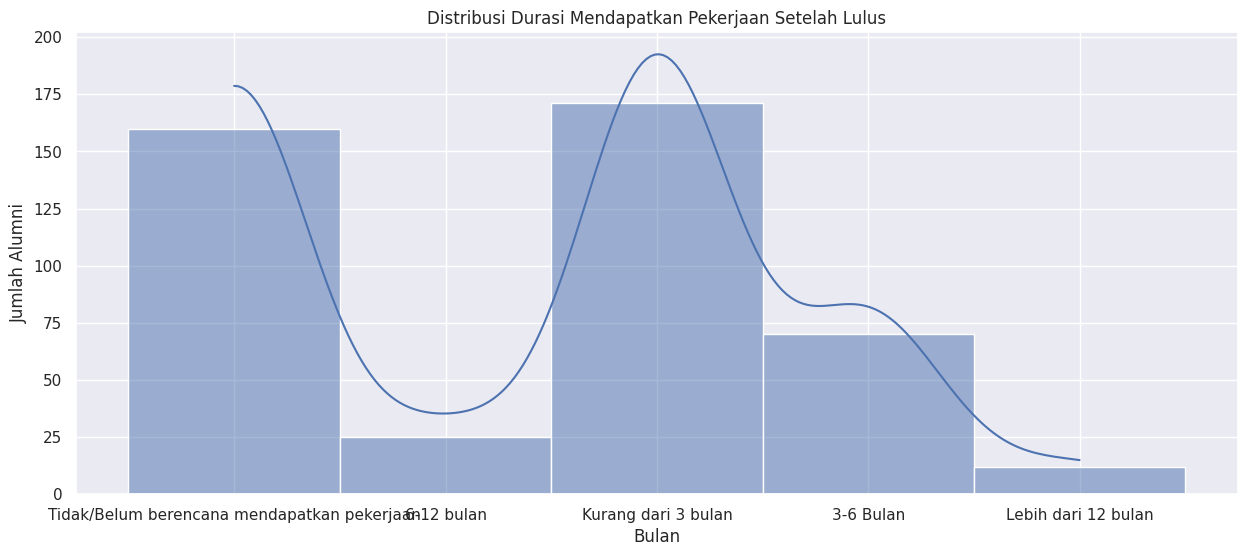

In [ ]:
# Visualisasi Distribusi Waktu Mendapatkan Pekerjaan
plt.figure(figsize=(15, 6))
sns.histplot(df['Waktu Mendapatkan Pekerjaan:'], bins=15, kde=True)
plt.title('Distribusi Durasi Mendapatkan Pekerjaan Setelah Lulus')
plt.xlabel('Bulan')
plt.ylabel('Jumlah Alumni')
plt.show()

**Distribusi Durasi Mendapatkan Pekerjaan Setalah Lulus**

Berdasarkan plot histogram dapat dilihat bahwa alumni yang mendapatkan pekerjaan :


1.   **Kurang dari 3 bulan :** berdasarkan histogram mayoritas alumni mendapatkan pekerjaan kurang dari 3 bulan, itu artinya mayoritas lulusan FST UIN Syarif HIdayatullah Jakarta mampu bersaing di dunia kerja, dibuktikan dengan waktu masuk ke dunia kerja yang relatif singkat.
2.   **3-6 bulan :** waktu dan jumlah yang relatif standar dalam memperoleh pekerjaan dan jumlah alumninya pun tidak banyak.
3. **6-12 bulan :** Sedikit alumni yang mendapatkan pekerjaan >6 bulan, itu berarti alumni FST UIN Syarif Hidayatullah Jakarta memiliki kompetensi dan ilmu yang relevan dengan industri saat ini sehingga alumni yang menapatkan pekerjaa >6 bulan jumlahnya tidak banyk.
3. **Lebih dari 12 bulan :** Sedikit sekali alumni yang mendapatkan pekerjaan >12 bulan itu berarti tidak dapat mewakili rata-rata alumni FST dalam mendapatkan pekerjaan. Di asumsikan bahwa alumni yang mendapatkan pekerjaan >12 bulan memang berniat melanjutkan study (tidak langsung bekerja) dikarenakan tidak sedikit alumni FST yang melanjutkan study S2 dan S3.
4. **Tidak/Belum berencana Mendapatkan Pekerjaan :** Banyak alumni yang memilih tidak bekerja atau berencana untuk tidak bekerja(berwirausaha). Jumlahnya hampir sama dengan alumni yang mendapatkan pekerjaan <3 bulan. Jika yang belum berencana bekerja dikarenakan melanjutkan study tidak masalah tetapi jika alasannya ingin berwirausaha sebaiknya kampus memfasilitasi hal tersebut karena berwirausaha bukan hal yang mudah.

**Rekomendasi**


1.   **Monitoring Tracer Study :** Monitoring dapat dilakukan secara berkala, misalnya setahun sekali untuk melihat apakah tren alumni dalam mendapatkan pekerjaan semakin meningkat atau malah menurun. Jika tracer study alumni dalam mendapatkan pekrjaan cenderung menurun atau banyak alumni yang mendapatkan pekerjaaan >6 bulan maka kampus perlu mengadakan workshop atau mentorship dan program pendukung karir selama perkuliahan harus lebih ditingkatkan. Monitoring ini juga dapat menilai efektivitas program pendukung karir di FST.
2.   **Evaluasi Kurikum dan Relevansi Kompetensi :** Tracer study bisa menjadi bahan evaluasi dari para alumni yang sudah bekerja apakah kurikulum yang di ajarkan di kampus masih sesuai atau relevan dengan dunia kerja atau tidak.
3. **Membangun Program Wirausaha :** dikarenakan ada alumni yang belum atau tidak berencana bekerja (mungkin ingin berwirausaha) tetapi masih sedikit sekali alumni yang memilih berwirausaha setelah lulus maka kampus sebaiknya meningkatkan dan memperkuat program pelatihan kewirausahaan seperti pelatihan bisnis atau pendanaan awal bagi mereka yang ingin berwirausaha.

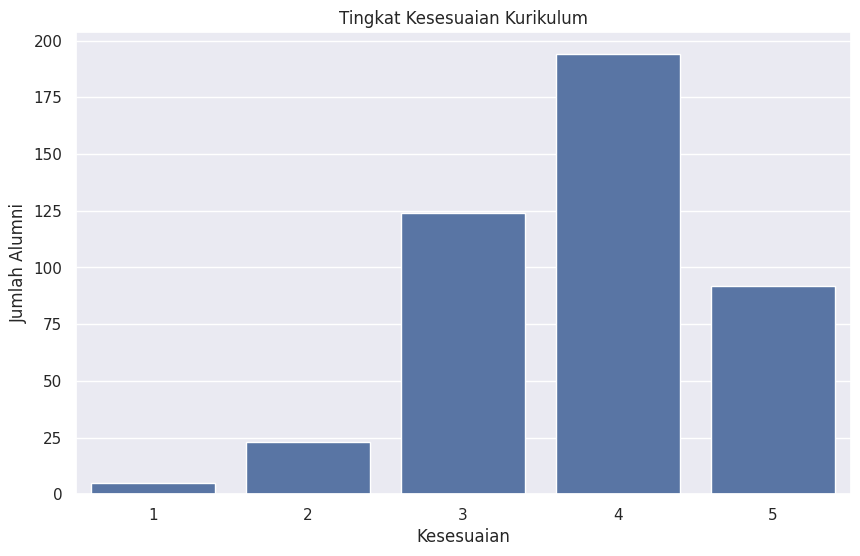

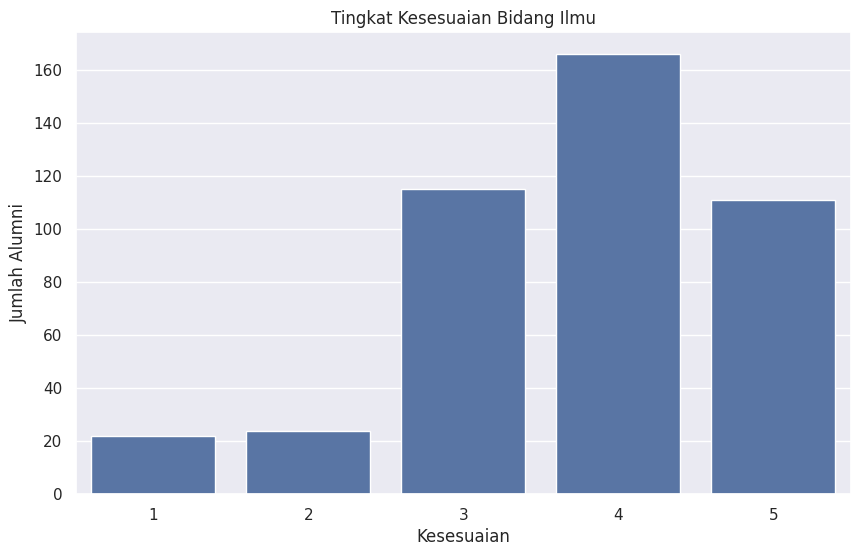

In [ ]:
# Visualisasi Kesesuaian Kurikulum dan Bidang Ilmu
plt.figure(figsize=(10, 6))
sns.countplot(x='Kesesuaian Kurikulum:', data=df, order=[1, 2, 3, 4, 5])
plt.title('Tingkat Kesesuaian Kurikulum')
plt.xlabel('Kesesuaian')
plt.ylabel('Jumlah Alumni')
plt.show()

plt.figure(figsize=(10, 6))
sns.countplot(x='Kesesuaian Bidang Ilmu:', data=df, order=[1, 2, 3, 4, 5])
plt.title('Tingkat Kesesuaian Bidang Ilmu')
plt.xlabel('Kesesuaian')
plt.ylabel('Jumlah Alumni')
plt.show()


**Tingkat Kesesuaian Kurikulum dan Bidang Ilmu**

Berdasarkan histogram, para alumni menunjukkan tingkat kepuasan yang baik terhadap kesesuaian kurikulum dan bidang ilmu yang diajarkan di masing-masing program studi di FST.

**Rekomendasi**
- **Mempertahankan Kualitas Pendidikan:** Berdasarkan survei kepuasan alumni, program studi di FST memiliki kurikulum dan bidang ilmu yang relevan dan berkualitas sesuai kebutuhan dunia kerja. Kualitas ini perlu dipertahankan dan ditingkatkan agar tidak mengalami penurunan.
- **Monitoring Kesesuaian Kurikulum dan Bidang Ilmu:** Saat ini, kurikulum dan bidang ilmu yang diajarkan mungkin masih relevan dengan dunia kerja. Namun, dalam 5-10 tahun mendatang, tanpa pembaruan, kurikulum tersebut bisa kehilangan relevansinya, menyulitkan alumni bersaing di dunia kerja. Oleh karena itu, perlu adanya monitoring berkala untuk memastikan kurikulum dan bidang ilmu tetap mengikuti perkembangan terkini.

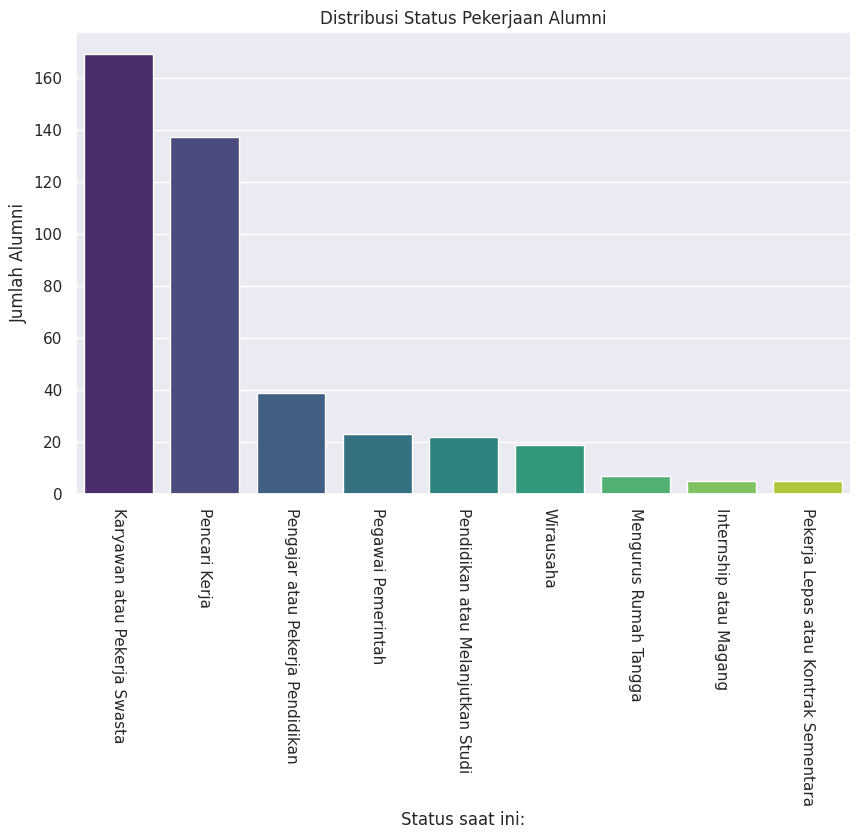

In [ ]:
# Hitung distribusi 'Status saat ini'
status_counts = df['Status saat ini:'].value_counts()
status_percent = (status_counts / status_counts.sum()) * 100  # Menghitung persentase

# Visualisasi Bar ChartChartChartChart
plt.figure(figsize=(10, 6))
sns.barplot(x=status_counts.index, y=status_counts.values, palette="viridis")
plt.title("Distribusi Status Pekerjaan Alumni")
plt.xlabel("Status saat ini:")
plt.ylabel("Jumlah Alumni")
plt.xticks(rotation=270)
plt.show()


**Distribusi Status Pekerjaan Alumni**

Saat ini, sebagian besar alumni bekerja sebagai karyawan atau pekerja di sektor swasta. Namun, cukup banyak juga alumni yang masih mencari pekerjaan. Kondisi ini perlu menjadi perhatian fakultas, karena jumlah alumni yang belum bekerja tergolong signifikan dan memerlukan tindak lanjut.

**Rekomendasi**
- **Program Pelatihan untuk Alumni:** Fakultas dapat mengadakan program pelatihan sesuai dengan bidang ilmu yang diajarkan dan atau workshop tentang kewirausahaan atau cara membangun start-up.
- **Peningkatan Kerja Sama dengan Industri:** Prodi sebaiknya memperluas kerja sama dengan perusahaan swasta untuk memberikan lebih banyak kesempatan magang atau PKL yang berkualitas, sehingga mahasiswa memiliki peluang lebih besar untuk diterima bekerja di tempat magang setelah lulus.
- **Program Sharing dengan Alumni:** Mengadakan sesi berbagi pengalaman dengan alumni dapat membantu mahasiswa memahami dunia kerja yang sebenarnya. Alumni bisa berbagi tips dan strategi untuk mendapatkan pekerjaan.

Distribusi Program Studi vs Status Saat Ini:
Status saat ini:        Internship atau Magang  Karyawan atau Pekerja Swasta  \
Program Studi                                                                  
Agribisnis S1                              0.0                          12.0   
Agribisnis S2                              0.0                           0.0   
Biologi S1                                 3.0                          33.0   
Fisika S1                                  0.0                          21.0   
Kimia S1                                   0.0                          18.0   
Matematika S1                              1.0                          33.0   
Prodi MAG                                  0.0                           1.0   
Teknik Informatika S1                      0.0                          44.0   
Teknik Pertambangan S1                     1.0                           7.0   

Status saat ini:        Mengurus Rumah Tangga  Pegawai Pemerintah  \
Progr

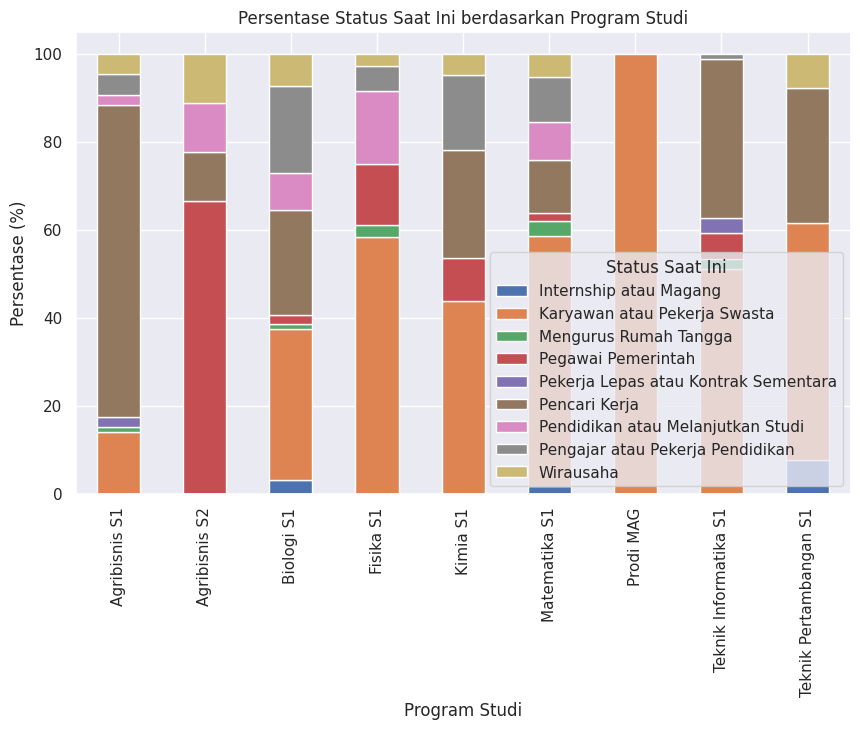

In [ ]:
# Menghitung jumlah alumni tiap 'Status Saat Ini' berdasarkan 'Program Studi'
program_studi_vs_status = df.groupby(['Program Studi', 'Status saat ini:']).size().unstack().fillna(0)

print("Distribusi Program Studi vs Status Saat Ini:")
print(program_studi_vs_status)

# Menambahkan persentase agar lebih mudah dianalisis
program_studi_vs_status_percent = program_studi_vs_status.div(program_studi_vs_status.sum(axis=1), axis=0) * 100

print("\nDistribusi Persentase Program Studi vs Status Saat Ini:")
print(program_studi_vs_status_percent)

# Visualisasi menggunakan plot untuk membantu melihat perbedaan
# Plot Distribusi Status Saat Ini per Program Studi
program_studi_vs_status_percent.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title('Persentase Status Saat Ini berdasarkan Program Studi')
plt.xlabel('Program Studi')
plt.ylabel('Persentase (%)')
plt.legend(title='Status Saat Ini')
plt.show()

* Setiap program studi memiliki persebaran status alumni yang cukup beragam, hal ini dapat membantu dalam merencanakan karier masa depan dengan melihat tren dan peluang kerja yang tersedia untuk lulusan dari program studi yang sama.

* Program studi dengan persentase pencari kerja yang cukup tinggi dapat mengevaluasi relevansi kurikulum dengan kebutuhan pasar kerja dan melakukan penyesuaian jika diperlukan.

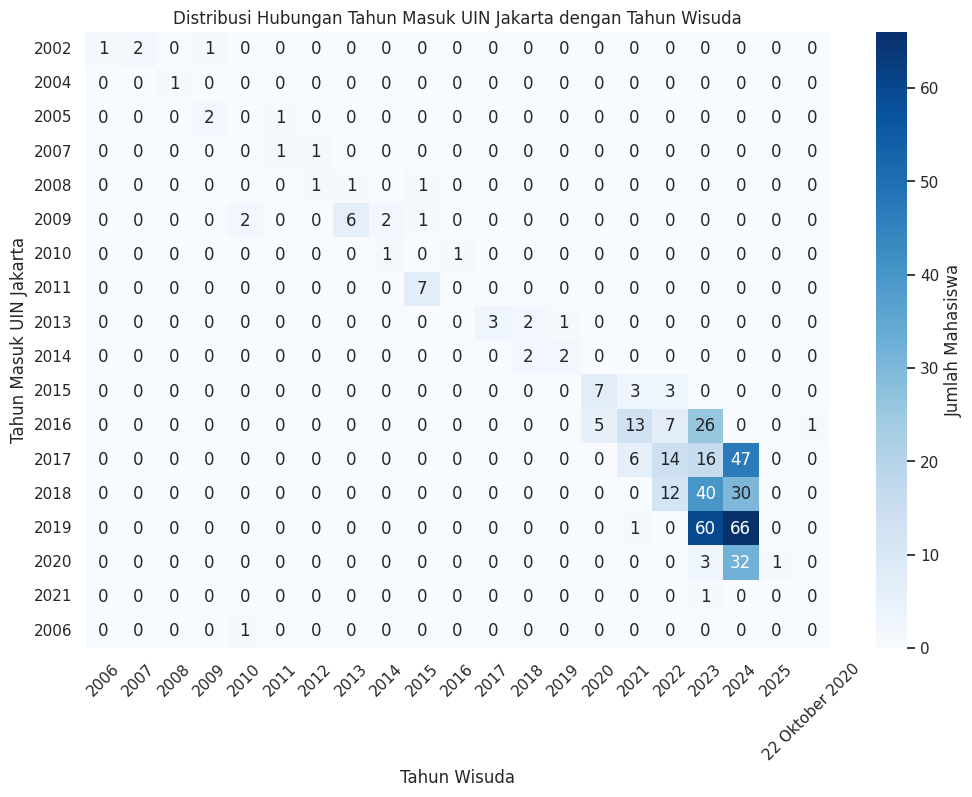

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Pastikan data sudah di-load dan tersimpan dalam DataFrame bernama 'df'
# Misalnya df memiliki kolom 'Tahun Masuk UIN Jakarta' dan 'Tahun Wisuda'

# Menghitung jumlah mahasiswa berdasarkan Tahun Masuk dan Tahun Wisuda
tahun_masuk_vs_wisuda = df.groupby(['Tahun Masuk UIN Jakarta', 'Tahun Wisuda']).size().unstack(fill_value=0)

# Membuat visualisasi heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tahun_masuk_vs_wisuda, annot=True, fmt="d", cmap="Blues", cbar_kws={'label': 'Jumlah Mahasiswa'})
plt.title("Distribusi Hubungan Tahun Masuk UIN Jakarta dengan Tahun Wisuda")
plt.xlabel("Tahun Wisuda")
plt.ylabel("Tahun Masuk UIN Jakarta")
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


**Hubungan Antara Tahun Masuk UIN Jakarta dengan Tahun Wisuda**

Berdasarkan heatmap dari kedua distribusi terlihat bahwa angkatan yang paling banyak mengisi survey adalah angkatan 2019 (angkatan termuda di survey) sebanyak 127 orang dan yang paling banyak melaksanakan wisuda ada di tahun 2024 (tahun terakhir pelaksanaan wisuda). Terlihat bahwa sebanyak 66 mahasiswa angkatan 2019 melaksanakan wisuda pada tahun 2024. Itu berarti 50% mahasiswa angkatan 2019 menyelesaikan studi lebih dari 4 tahun. Begitu pula dengan mahasiswa angkatan 2017 dan 2018 yang menyelesaikan studi lebih dari 4 tahun juga tergolong banyak. Ini dapat menjadi bahan evalusi bagi prodi dan fakultas.

**Rekomendasi**
1. **Dukungan Bimbingan Akademik :** Dikarenakan cukup banyak mahasiswa yang menyelesaikan studi lebih dari 4 tahun maka prodi dapat mengevaluasi apakah mahasiswa yang menyelsaikan studi lebih dari 4 tahun dikarenakan kesulitan dalam mengikuti pelajaran atau masalah lainnya di luar kampus. Jika mayoritas masalah yang di alami adalah kesulitan dalam mengikuti pelajaran maka fakultas dapat meningkatkan bimbingan akademik seperti penambahan dosen pembimbing dan atau mengadakan sesi tambahan untuk memastikan mahasiswa dapat lulus tepat waktu sesuai kurikulum.
2. **Kemudahan dalam masa skripsi dan proses wisuda :** Tidak dapat dipungkiri bahwa kesulitan mahasiswa dalam proses skripsi tidak hanya keterbatasan kemampuan tetapi juga ada faktor lainnya seperti dosen yang sulit ditemui untuk bimbingan dan proses administrasi wisuda yang cukup panjang yang membuat mahasiswa yang mungkin memiliki waktu terbatas setelah menyelesaikan proses skripsi harus mendaftar di wisuda seanjutnya.

#**Clustering**

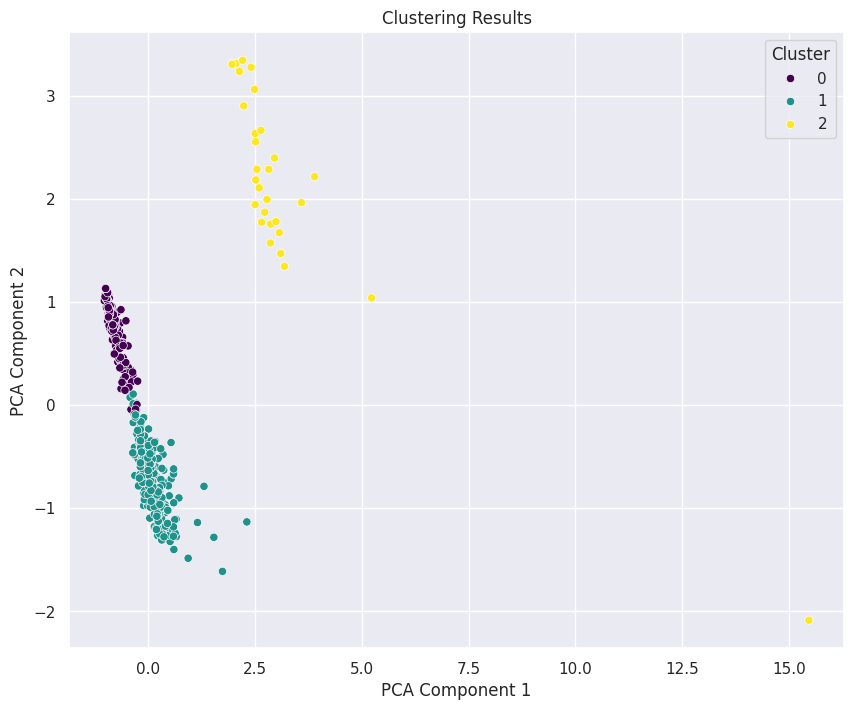

Loading Scores:
                                           PC1       PC2
Penghasilan                           0.656079 -0.208868
Tahun Wirausaha                       0.620171  0.586333
Tahun Masuk UIN Jakarta_2004         -0.000336 -0.000707
Tahun Masuk UIN Jakarta_2005          0.007974 -0.001111
Tahun Masuk UIN Jakarta_2006          0.001172 -0.002042
...                                        ...       ...
Program Studi_Kimia S1               -0.000467 -0.012281
Program Studi_Matematika S1           0.030342 -0.023492
Program Studi_Prodi MAG               0.000548 -0.002841
Program Studi_Teknik Informatika S1  -0.023183 -0.058483
Program Studi_Teknik Pertambangan S1 -0.001955  0.002226

[348 rows x 2 columns]


In [ ]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Menentukan kolom kategorikal dan numerik
categorical_columns = ['Tahun Masuk UIN Jakarta', 'Tahun Wisuda', 'Bulan Wisuda',
                       'Waktu Mendapatkan Pekerjaan:', 'Status saat ini:', 'Bidang wirausaha:',
                       'Posisi', 'Universitas', 'Nama jurusan/program studi setelah Kuliah di FST UIN Jakarta:',
                       'Kesesuaian Kurikulum:', 'Kesesuaian Bidang Ilmu:', 'Program Studi']
numerical_columns = ['Penghasilan', 'Tahun Wirausaha']

# Memastikan kolom yang dipilih ada dalam dataframe
categorical_columns = [col for col in categorical_columns if col in df.columns]
numerical_columns = [col for col in numerical_columns if col in df.columns]

# Mengganti 'None' dengan NaN di kolom numerik, lalu mengubah tipe data kolom numerik ke float
df[numerical_columns] = df[numerical_columns].replace('None', pd.NA).apply(pd.to_numeric, errors='coerce')

# Mengisi nilai NaN dengan median di kolom numerik
df[numerical_columns] = df[numerical_columns].fillna(df[numerical_columns].median())

# Preprocessing Pipeline: OneHotEncoder untuk kolom kategorikal dan StandarScaler untuk kolom numerik
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_columns),
        ('cat', OneHotEncoder(drop='first'), categorical_columns)
    ])

# Pipeline untuk preprocessing dan clustering
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('kmeans', KMeans(n_clusters=3, random_state=42))  # Misalnya, kita mulai dengan 3 klaster
])

# Fitting model
pipeline.fit(df)

# Mendapatkan hasil klaster
df['Cluster'] = pipeline.named_steps['kmeans'].labels_

# Visualisasi hasil klaster menggunakan PCA (2 komponen utama untuk visualisasi 2D)
pca = PCA(n_components=2)
df_pca = pca.fit_transform(pipeline.named_steps['preprocessor'].transform(df))

plt.figure(figsize=(10, 8))
sns.scatterplot(x=df_pca[:, 0], y=df_pca[:, 1], hue=df['Cluster'], palette='viridis')
plt.title('Clustering Results')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.legend(title='Cluster')
plt.show()

# Mendapatkan nama fitur setelah preprocessing (untuk interpretasi PCA loading scores)
# Menggabungkan nama fitur numerik dan fitur hasil encoding
numerical_feature_names = numerical_columns
categorical_feature_names = pipeline.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(categorical_columns)
feature_names = list(numerical_feature_names) + list(categorical_feature_names)

# Mendapatkan loading scores untuk setiap fitur dalam PCA
loading_scores = pd.DataFrame(pca.components_.T, columns=['PC1', 'PC2'], index=feature_names)

# Menampilkan loading scores
print("Loading Scores:")
print(loading_scores)


*   Penghasilan (0.656079) dan Tahun Wirausaha (0.620171) memiliki nilai loading yang tinggi pada PC1, menunjukkan bahwa perbedaan dalam penghasilan dan tahun memulai usaha adalah faktor utama dalam membedakan data pada dimensi pertama. Hal ini berarti individu dengan variasi dalam penghasilan dan tahun wirausaha cenderung terpisah di sepanjang komponen utama ini.
Cluster yang terbentuk sepanjang komponen utama ini kemungkinan besar dipengaruhi oleh perbedaan penghasilan dan pengalaman wirausaha.
Fitur ini mungkin memengaruhi kecenderungan untuk masuk ke dalam cluster tertentu, di mana penghasilan dan pengalaman wirausaha memiliki pengaruh yang besar.
*   Tahun Wirausaha (0.586333) dan beberapa variabel kategori seperti Program Studi mungkin memiliki pengaruh terhadap PC2, namun nilainya tetap lebih rendah dibandingkan kontribusi Penghasilan dan Tahun Wirausaha pada PC1.
Tahun Wirausaha juga memiliki pengaruh yang signifikan di sepanjang PC2, menunjukkan bahwa individu dengan variasi dalam tahun wirausaha bisa berbeda di sepanjang dimensi ini juga.

Secara keseluruhan, Penghasilan dan Tahun Wirausaha adalah dua fitur yang paling menentukan dalam analisis ini, sedangkan fitur lain seperti Tahun Masuk UIN dan Program Studi memberikan kontribusi yang relatif kecil dalam perbedaan antar data di PCA.

**Kesimpulan Clustering**

*   Cluster 0 (Ungu): kemungkinan terdiri dari individu yang memiliki tingkat penghasilan dan pengalaman yang sedikit lebih rendah dalam wirausaha dibandingkan Cluster 1.
*   Cluster 1 (Hijau): mencakup individu dengan sedikit lebih banyak pengalaman atau penghasilan dalam wirausaha, meskipun perbedaannya mungkin tidak ekstrem dengan cluster 0.
*   Cluster 2 (Kuning): Memiliki nilai PC1 dan PC2 yang tinggi, kemungkinan terdiri dari individu dengan penghasilan dan tahun pengalaman yang lebih tinggi dibandingkan cluster lainnya.

Berdasarkan hasil clustering ini, berikut adalah rekomendasi yang dapat diberikan:

Alumni dari kelompok Kuning atau yang memiliki penghasilan dan pengalaman wirausaha yang lebiih lama dapat memberikan Pelatihan Dasar Wirausaha dan Mentorship serta Dukungan Pembiayaan kepada mahasiswa FST yang tertarik untuk berwirausaha.